# PTB-XL ECG Dataset - Data Exploration

**Course:** AAI-501 - Introduction to AI and Machine Learning  
**Project:** ECG Arrhythmia Classification  
**Part:** 1 - Data Preparation & EDA  
**Author:** Ashok Bhairwal

## Objectives
1. Load and understand the PTB-XL dataset structure
2. Explore metadata and patient demographics
3. Analyze diagnostic label distribution
4. Visualize sample ECG signals
5. Identify data quality issues

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import ast
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("Libraries loaded successfully!")

Libraries loaded successfully!


## 1. Load Dataset

In [2]:
# Define paths
DATA_PATH = Path('../data/raw/physionet.org/files/ptb-xl/1.0.3')
SAMPLING_RATE = 100  # Use 100 Hz for faster processing
# Save enhanced metadata
OUTPUT_PATH = Path('../data/preprocessed')
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

# Load metadata
df = pd.read_csv(DATA_PATH / 'ptbxl_database.csv', index_col='ecg_id')
print(f"Dataset shape: {df.shape}")
print(f"Total ECG records: {len(df)}")
print(f"Total patients: {df['patient_id'].nunique()}")
df.head()

Dataset shape: (21799, 27)
Total ECG records: 21799
Total patients: 18869


,patient_id,age,sex,height,weight,nurse,site,device,recording_date,report,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,sinusrhythmus periphere niederspannung,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,sinusbradykardie sonst normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,sinusrhythmus normales ekg,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,sinusrhythmus normales ekg,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,sinusrhythmus normales ekg,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [3]:
# Column names and descriptions
print("\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


Column Names:
 1. patient_id
 2. age
 3. sex
 4. height
 5. weight
 6. nurse
 7. site
 8. device
 9. recording_date
10. report
11. scp_codes
12. heart_axis
13. infarction_stadium1
14. infarction_stadium2
15. validated_by
16. second_opinion
17. initial_autogenerated_report
18. validated_by_human
19. baseline_drift
20. static_noise
21. burst_noise
22. electrodes_problems
23. extra_beats
24. pacemaker
25. strat_fold
26. filename_lr
27. filename_hr


In [4]:
selected_columns = [
    "patient_id", "age", "sex", "height", "weight", "nurse", "site",
    "device", "recording_date", "report", "scp_codes", "heart_axis",
    "infarction_stadium1", "infarction_stadium2", "validated_by",
    "second_opinion", "initial_autogenerated_report", "validated_by_human",
    "baseline_drift", "static_noise", "burst_noise",
    "electrodes_problems", "extra_beats", "pacemaker",
    "strat_fold", "filename_lr", "filename_hr"
]

# Only select columns that actually exist in the dataframe
existing_cols = [col for col in selected_columns if col in df.columns]
missing_cols = [col for col in selected_columns if col not in df.columns]
df_metadata = df[existing_cols].copy()
if missing_cols:
    print(f"Note: The following columns don't exist yet and will be skipped: {missing_cols}")
    print(f"      These will be added after diagnostic labels are created in Section 3")
else :
    print(f"No missing columns found in the dataset as Shape is {df_metadata.shape}")


No missing columns found in the dataset as Shape is (21799, 27)


## 2.  Data Cleaning

#### 2a. Identifying and Removing Missing Data

This step removes ECG records for patients whose required ECG files (.dat and .hea) are missing.

In [5]:
# Check for missing files AND filter dataset
missing_dat = []
missing_hea = []
missing_both = []
valid_records = []
print("="*70)
# Check each record
for ecg_id, row in df.iterrows():
    patient_id = int(row['patient_id'])
    filename_lr = row['filename_lr']
    
    # Construct file paths
    base_path = DATA_PATH / filename_lr
    dat_file = Path(str(base_path) + '.dat')
    hea_file = Path(str(base_path) + '.hea')
    
    # Check existence
    dat_exists = dat_file.exists()
    hea_exists = hea_file.exists()
    
    # Categorize
    if not dat_exists and not hea_exists:
        missing_both.append((ecg_id, patient_id))
    elif not dat_exists:
        missing_dat.append((ecg_id, patient_id))
    elif not hea_exists:
        missing_hea.append((ecg_id, patient_id))
    else:
        valid_records.append(ecg_id)

# Get unique patient IDs with any missing file
all_missing_patients = set()
for ecg_id, patient_id in missing_dat + missing_hea + missing_both:
    all_missing_patients.add(patient_id)
all_missing_patients = sorted(list(all_missing_patients))

# Print summary
print(f"RESULTS:")
print("="*70)
print(f"Total records checked:      {len(df):,}")
print(f"Valid records (both files): {len(valid_records):,}")
print(f"Missing .dat only:          {len(missing_dat)} records")
print(f"Missing .hea only:          {len(missing_hea)} records")
print(f"Missing both files:         {len(missing_both)} records")
print(f"Total records to remove:    {len(missing_dat) + len(missing_hea) + len(missing_both)}")
print(f"Unique patient IDs affected: {len(all_missing_patients)}")


# FILTER DATASET - Remove records with missing files
print("\n" + "="*70)
print("FILTERING DATASET")
print("="*70)

df_original = df.copy()
original_count = len(df)

# Keep only valid records
df = df.loc[valid_records]

removed_count = original_count - len(df)

print(f"\nFiltered Dataset shape: {df.shape}")

RESULTS:
Total records checked:      21,799
Valid records (both files): 21,762
Missing .dat only:          19 records
Missing .hea only:          18 records
Missing both files:         0 records
Total records to remove:    37
Unique patient IDs affected: 37

FILTERING DATASET

Filtered Dataset shape: (21762, 27)


-------------
#### 2b. Remove Records with Missing Core Identifiers

**Core identifiers** are essential columns that must have values for a record to be valid:
- `patient_id` - Patient identifier
- `scp_codes` - Diagnostic codes (cannot be empty)

Records with missing values in any of these columns will be removed.

In [6]:
# Define core identifiers - these MUST have values
core_identifiers = ['patient_id', 'scp_codes']  # ecg_id is the index

initial_count = len(df)
print(f"Initial record count: {initial_count:,}")

# Check each core identifier
print("Checking core identifiers:")
print("-"*70)

records_to_remove = set()

# Check patient_id
if 'patient_id' in df.columns:
    missing_patient_id = df[df['patient_id'].isna()].index.tolist()
    if missing_patient_id:
        print(f"  patient_id - Missing: {len(missing_patient_id)} records")
        records_to_remove.update(missing_patient_id)
    else:
        print(f"  patient_id - OK: All records have patient_id")
else:
    print(f"  patient_id - WARNING: Column not found")

# Check scp_codes
if 'scp_codes' in df.columns:
    # Check for NaN or empty string
    missing_scp = df[df['scp_codes'].isna() | (df['scp_codes'].astype(str).str.strip() == '')].index.tolist()
    if missing_scp:
        print(f"  scp_codes  - Missing: {len(missing_scp)} records")
        records_to_remove.update(missing_scp)
    else:
        print(f"  scp_codes  - OK: All records have diagnostic codes")
else:
    print(f"  scp_codes  - WARNING: Column not found")

print("" + "="*70)
print(f"OK: Core identifier validation complete")
print("="*70)

Initial record count: 21,762
Checking core identifiers:
----------------------------------------------------------------------
  patient_id - OK: All records have patient_id
  scp_codes  - OK: All records have diagnostic codes
OK: Core identifier validation complete


#### 2c. Remove Duplicate ECG Records (Keep Latest)

Some patients have multiple ECG recordings. This step keeps only the **LATEST** (most recent) record based on `recording_date`.

**Strategy:** Sort by date (descending) and keep the first record per patient.

In [7]:
# Remove duplicate ECG records - Keep LATEST (most recent) per patient
print("" + "="*70)
print("SECTION 2c: REMOVING DUPLICATE ECG RECORDS (Keeping Latest)")
print("="*70)

# Statistics before
total_patients = df['patient_id'].nunique()
total_records = len(df)
print(f"Before deduplication:")
print(f"  Total records:           {total_records:,}")
print(f"  Unique patients:         {total_patients:,}")
print(f"  Avg records per patient: {total_records/total_patients:.2f}")

# Convert recording_date to datetime for proper sorting
df['recording_date_dt'] = pd.to_datetime(df['recording_date'])

# Show example of patient with multiple records
patients_with_multiple = df['patient_id'].value_counts()
patients_with_multiple = patients_with_multiple[patients_with_multiple > 1]
if len(patients_with_multiple) > 0:
    sample_patient = patients_with_multiple.index[0]
    sample_records = df[df['patient_id'] == sample_patient][['patient_id', 'recording_date']].sort_values('recording_date')
    print(f"Example - Patient {int(sample_patient):05d} has {len(sample_records)} records:")
    for idx, row in sample_records.iterrows():
        print(f"  ECG_ID {idx}: {row['recording_date']}")

# Sort by recording_date (descending) and keep LATEST (first after sorting)
df_before_dedup = df.copy()
df = df.sort_values('recording_date_dt', ascending=False).drop_duplicates(subset='patient_id', keep='first')

# Drop the temporary datetime column
df = df.drop(columns=['recording_date_dt'])

records_removed = len(df_before_dedup) - len(df)

print(f"After deduplication (keeping LATEST/most recent):")
print(f"  Records remaining: {len(df):,}")
print(f"  Unique patients:   {df['patient_id'].nunique():,}")
print(f"  Records removed:   {records_removed:,}")

# Show what was kept for the example patient
if len(patients_with_multiple) > 0:
    kept_record = df[df['patient_id'] == sample_patient]
    if len(kept_record) > 0:
        kept_idx = kept_record.index[0]
        kept_date = kept_record.iloc[0]['recording_date']
        print(f"  -> Kept ECG_ID {kept_idx} ({kept_date}) - the LATEST for patient {int(sample_patient):05d}")

# Verify
assert len(df) == df['patient_id'].nunique(), "ERROR: Still have duplicates!"
print(f"OK: Verification passed - ONE record per patient (latest/most recent)")
print("="*70)

SECTION 2c: REMOVING DUPLICATE ECG RECORDS (Keeping Latest)
Before deduplication:
  Total records:           21,762
  Unique patients:         18,843
  Avg records per patient: 1.15
Example - Patient 09898 has 10 records:
  ECG_ID 12633: 1994-07-31 10:11:47
  ECG_ID 12737: 1994-08-09 09:38:20
  ECG_ID 12793: 1994-08-15 06:47:31
  ECG_ID 12797: 1994-08-16 09:31:19
  ECG_ID 12800: 1994-08-17 05:24:27
  ECG_ID 12808: 1994-08-18 05:28:52
  ECG_ID 12821: 1994-08-21 05:25:13
  ECG_ID 12827: 1994-08-22 05:31:42
  ECG_ID 12831: 1994-08-23 05:44:01
  ECG_ID 12865: 1994-09-01 06:53:00
After deduplication (keeping LATEST/most recent):
  Records remaining: 18,843
  Unique patients:   18,843
  Records removed:   2,919
  -> Kept ECG_ID 12865 (1994-09-01 06:53:00) - the LATEST for patient 09898
OK: Verification passed - ONE record per patient (latest/most recent)


#### 2d. Identify and Remove Outliers

Remove records with unrealistic or extreme values using:
1. **Domain knowledge** - Impossible values (age > 120, unrealistic height/weight)
2. **Statistical methods** - IQR (Interquartile Range) for extreme outliers

In [8]:
# Identify and remove outliers
print("="*70)
print("IDENTIFYING AND REMOVING OUTLIERS")
print("="*70)

df_before_outliers = df.copy()
initial_count = len(df)
outlier_records = set()

# 1. DOMAIN-BASED OUTLIERS
print("1. Domain-Based Outlier Detection:")
print("-"*70)

# Age outliers
age_min, age_max = 0, 120
age_outliers = df[(df['age'] < age_min) | (df['age'] > age_max)].index.tolist()
if age_outliers:
    print(f"  Age outliers: {len(age_outliers)} records (range: {df.loc[age_outliers, 'age'].min():.0f}-{df.loc[age_outliers, 'age'].max():.0f})")
    outlier_records.update(age_outliers)
else:
    print(f"  Age: No outliers (all within {age_min}-{age_max} years)")

# Height outliers
if 'height' in df.columns:
    height_min, height_max = 50, 250  # cm
    height_outliers = df[(df['height'] < height_min) | (df['height'] > height_max)].index.tolist()
    if height_outliers:
        print(f"  Height outliers: {len(height_outliers)} records")
        outlier_records.update(height_outliers)
    else:
        print(f"  Height: No outliers (all within {height_min}-{height_max} cm)")

# Weight outliers
if 'weight' in df.columns:
    weight_min, weight_max = 20, 300  # kg
    weight_outliers = df[(df['weight'] < weight_min) | (df['weight'] > weight_max)].index.tolist()
    if weight_outliers:
        print(f"  Weight outliers: {len(weight_outliers)} records")
        outlier_records.update(weight_outliers)
    else:
        print(f"  Weight: No outliers (all within {weight_min}-{weight_max} kg)")

# 2. STATISTICAL OUTLIERS (IQR method for age)
print("2. Statistical Outlier Detection (IQR):")
print("-"*70)

Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1
age_lower = Q1 - 3.0 * IQR
age_upper = Q3 + 3.0 * IQR

age_iqr_outliers = df[(df['age'] < age_lower) | (df['age'] > age_upper)].index.tolist()
if age_iqr_outliers:
    print(f"  Age IQR outliers: {len(age_iqr_outliers)} records")
    print(f"  IQR bounds: {age_lower:.1f} - {age_upper:.1f} years")
    outlier_records.update(age_iqr_outliers)
else:
    print(f"  Age: No IQR outliers")

# 3. REMOVE OUTLIERS
print("3. Removing Outliers:")
print("-"*70)

unique_outliers = list(outlier_records)
print(f"  Total unique outliers: {len(unique_outliers)}")

if len(unique_outliers) > 0:
    # Save outlier records
    outlier_df = df.loc[unique_outliers].copy()
    outlier_df.to_csv(OUTPUT_PATH / 'outlier_records.csv')
    print(f"  -> Saved to: {OUTPUT_PATH / 'outlier_records.csv'}")
    
    # Show sample
    print(f"Sample outliers (first 5):")
    sample_cols = ['patient_id', 'age', 'sex']
    if 'height' in df.columns:
        sample_cols.append('height')
    if 'weight' in df.columns:
        sample_cols.append('weight')
    print(df.loc[unique_outliers, sample_cols].head(5).to_string())

# Remove outliers
df = df.drop(index=unique_outliers)
removed_count = initial_count - len(df)

print(f"Before outlier removal: {initial_count:,} records")
print(f"After outlier removal:  {len(df):,} records")
print(f"Records removed:        {removed_count:,}")
print(f"Remaining patients:     {df['patient_id'].nunique():,}")

# Final statistics
print("4. Cleaned Data Statistics:")
print("-"*70)
print(f"  Age: Mean={df['age'].mean():.1f}, Median={df['age'].median():.1f}, Range={df['age'].min():.0f}-{df['age'].max():.0f}")

print("" + "="*70)
print(f"OK: Outlier removal complete")
print("="*70)

IDENTIFYING AND REMOVING OUTLIERS
1. Domain-Based Outlier Detection:
----------------------------------------------------------------------
  Age outliers: 262 records (range: 300-300)
  Height outliers: 3 records
  Weight outliers: 9 records
2. Statistical Outlier Detection (IQR):
----------------------------------------------------------------------
  Age IQR outliers: 262 records
  IQR bounds: -20.0 - 141.0 years
3. Removing Outliers:
----------------------------------------------------------------------
  Total unique outliers: 274
  -> Saved to: ..\data\preprocessed\outlier_records.csv
Sample outliers (first 5):
        patient_id    age  sex  height  weight
ecg_id                                        
9732        6910.0  300.0    1   152.0    49.0
3077        7605.0  300.0    1   155.0    59.0
6664        6047.0  300.0    1   164.0    64.0
9736        1681.0    3.0    1   100.0    16.0
12816       9567.0  300.0    0     NaN     NaN
Before outlier removal: 18,843 records
After o

-------------------
## 3. Data preprocessing

#### 3a. Convert Quality Indicators to Binary Flags

**Quality indicators** track signal quality issues. In the raw data:
- **NaN (missing)** = No issue detected (convert to 0)
- **Non-NaN (has value)** = Issue present (Keep it as it is)

Quality indicators:
- `baseline_drift` - Baseline wander in ECG signal
- `static_noise` - Static/electrical noise
- `burst_noise` - Sudden noise bursts
- `electrodes_problems` - Electrode connection issues
- `extra_beats` - Premature/extra heartbeats
- `pacemaker` - Pacemaker artifacts

In [9]:
# Handle quality indicators: NaN = 0 (no issue), keep original value if present
print("" + "="*70)
print("SECTION 3a: HANDLING QUALITY INDICATORS")
print("="*70)

# Define quality indicator columns
quality_indicators = [
    'baseline_drift', 'static_noise', 'burst_noise',
    'electrodes_problems', 'extra_beats', 'pacemaker'
]

print("Quality Indicators (NaN/empty = 0, else keep original value):")
print("-"*70)

# Check which columns exist and handle them
handled_cols = []
for col in quality_indicators:
    if col in df.columns:
        # Count before handling
        missing_count = df[col].isna().sum()
        has_value_count = df[col].notna().sum()
        
        print(f"  {col:25s}: {missing_count:5,} empty (->0), {has_value_count:5,} have values (keep as is)")
        
        # Fill NaN with 0, keep other values as is
        df[col] = df[col].fillna(0)
        
        handled_cols.append(col)
    else:
        print(f"  {col:25s}: Column not found (skipping)")

print("" + "-"*70)
print("HANDLING RESULTS:")
print("-"*70)

if handled_cols:
    print(f"  Handled {len(handled_cols)} quality indicator columns")
    print(f"  Columns: {', '.join(handled_cols)}")
    
    # Show sample of data after handling
    print(f"  Sample of quality indicators after handling:")
    sample_df = df[handled_cols].head(10)
    print(sample_df.to_string())
    
    # Show data types
    print(f"  Data types after handling:")
    for col in handled_cols:
        dtype = df[col].dtype
        unique_vals = df[col].unique()[:5]  # First 5 unique values
        print(f"    {col:25s}: {dtype} (sample values: {unique_vals.tolist()})")
    
    # Count empty vs non-empty
    print(f"  Summary:")
    print("-"*70)
    for col in handled_cols:
        zero_count = (df[col] == 0).sum()
        non_zero_count = (df[col] != 0).sum()
        print(f"    {col:25s}: {zero_count:5,} = 0 (no issue), {non_zero_count:5,} != 0 (has issue)")
else:
    print(f"  No quality indicator columns found")

print("" + "="*70)
print(f"OK: Quality indicators handled - NaN replaced with 0, original values preserved")
print("="*70)

SECTION 3a: HANDLING QUALITY INDICATORS
Quality Indicators (NaN/empty = 0, else keep original value):
----------------------------------------------------------------------
  baseline_drift           : 17,201 empty (->0), 1,368 have values (keep as is)
  static_noise             : 15,901 empty (->0), 2,668 have values (keep as is)
  burst_noise              : 18,066 empty (->0),   503 have values (keep as is)
  electrodes_problems      : 18,542 empty (->0),    27 have values (keep as is)
  extra_beats              : 17,080 empty (->0), 1,489 have values (keep as is)
  pacemaker                : 18,346 empty (->0),   223 have values (keep as is)
----------------------------------------------------------------------
HANDLING RESULTS:
----------------------------------------------------------------------
  Handled 6 quality indicator columns
  Columns: baseline_drift, static_noise, burst_noise, electrodes_problems, extra_beats, pacemaker
  Sample of quality indicators after handling:
    

#### 3b. Save Cleaned Dataset

Save the cleaned and preprocessed dataset after all data cleaning steps:
- Missing files removed
- Missing core identifiers removed
- Duplicates removed (kept latest)
- Outliers removed
- Quality indicators converted

In [10]:
# Save cleaned dataset
print("="*70)
print("SAVING CLEANED DATASET")
print("="*70)

# Define output path
output_path = Path('../data/preprocessed')
output_path.mkdir(parents=True, exist_ok=True)

# Save cleaned dataset
output_file = OUTPUT_PATH / 'ptbxl_cleaned.csv'
df.to_csv(output_file)

print(f"Cleaned dataset saved:")
print(f"  File: {output_file}")
print(f"  Shape: {df.shape}")
print(f"  Records: {len(df):,}")
print(f"  Features: {len(df.columns)}")
print(f"  Size: {output_file.stat().st_size / 1024:.2f} KB")

# Save column information
print(f"Columns saved ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    non_null = df[col].notna().sum()
    null_count = df[col].isna().sum()
    dtype = df[col].dtype
    print(f"  {i:2d}. {col:30s} ({dtype}) - {non_null:,} non-null, {null_count:,} null")

# Summary statistics
print(f"" + "="*70)
print("CLEANING SUMMARY")
print("="*70)

# If we have original count from Section 1
if 'df_original' in dir() or 'original_count' in dir():
    try:
        original_count = len(df_original) if 'df_original' in dir() else original_count
        removed = original_count - len(df)
        pct_removed = (removed / original_count) * 100
        print(f"  Original records:  {original_count:,}")
        print(f"  Cleaned records:   {len(df):,}")
        print(f"  Records removed:   {removed:,} ({pct_removed:.2f}%)")
    except:
        print(f"  Final record count: {len(df):,}")
else:
    print(f"  Final record count: {len(df):,}")

print(f"  Unique patients:   {df['patient_id'].nunique():,}")
print(f"  Features:          {len(df.columns)}")

# Check if diagnostic labels exist
superclass_labels = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
existing_labels = [label for label in superclass_labels if label in df.columns]

if existing_labels:
    print(f"Diagnostic Label Distribution:")
    for label in existing_labels:
        count = df[label].sum()
        pct = (count / len(df)) * 100
        print(f"    {label:10s}: {count:6,} ({pct:5.2f}%)")

# Check quality indicators
quality_cols = ['baseline_drift', 'static_noise', 'burst_noise',
                'electrodes_problems', 'extra_beats', 'pacemaker']
existing_quality = [col for col in quality_cols if col in df.columns]

if existing_quality:
    total_issues = 0
    for col in existing_quality:
        if df[col].dtype == 'object':
            total_issues += (df[col] != 0).sum()
        else:
            total_issues += df[col].sum()
    
    clean_records = len(df) - (df[[col for col in existing_quality]].apply(
        lambda x: (x != 0).any(), axis=1).sum())
    clean_pct = (clean_records / len(df)) * 100
    
    print(f"Signal Quality:")
    print(f"    Clean records:     {clean_records:6,} ({clean_pct:5.2f}%)")
    print(f"    Records w/ issues: {len(df) - clean_records:6,} ({100-clean_pct:5.2f}%)")

print(f"" + "="*70)
print(f"✓ Cleaned dataset ready for analysis and modeling!")
print(f"✓ File: {output_file}")
print("="*70)

SAVING CLEANED DATASET
Cleaned dataset saved:
  File: ..\data\preprocessed\ptbxl_cleaned.csv
  Shape: (18569, 27)
  Records: 18,569
  Features: 27
  Size: 5516.91 KB
Columns saved (27):
   1. patient_id                     (float64) - 18,569 non-null, 0 null
   2. age                            (float64) - 18,569 non-null, 0 null
   3. sex                            (int64) - 18,569 non-null, 0 null
   4. height                         (float64) - 6,460 non-null, 12,109 null
   5. weight                         (float64) - 8,663 non-null, 9,906 null
   6. nurse                          (float64) - 17,209 non-null, 1,360 null
   7. site                           (float64) - 18,557 non-null, 12 null
   8. device                         (str) - 18,569 non-null, 0 null
   9. recording_date                 (str) - 18,569 non-null, 0 null
  10. report                         (str) - 18,569 non-null, 0 null
  11. scp_codes                      (str) - 18,569 non-null, 0 null
  12. heart_axis 

## 4. Create Diagnostic Labels

**Purpose**: Transform diagnostic codes (`scp_codes`) into binary labels for classification.

The PTB-XL dataset uses SCP (Standard Communications Protocol) codes to represent diagnoses.
We'll map these to 6 diagnostic superclasses:


| Superclass | Code | Description & Conditions |
| :--- | :---: | :--- |
| **Normal Sinus Rhythm** | `NORM` | Standard, healthy electrical activity and rhythm without detectable abnormalities. |
| **Conduction Disturbance** | `CD` | Delays or blocks in the electrical pathway (e.g., Bundle Branch Blocks, AV Blocks). |
| **ST/T Segment Changes** | `STTC` | Repolarization anomalies often indicating myocardial ischemia, injury, or electrolyte imbalances. |
| **Myocardial Infarction** | `MI` | Waveform patterns indicating past or active heart muscle tissue damage. |
| **Hypertrophy** | `HYP` | Thickening/enlargement of heart chambers (e.g., **LVH** - Left Ventricular Hypertrophy, **RVH** - Right Ventricular Hypertrophy). |



**Multi-label**: A single ECG can have multiple diagnoses (e.g., both NORM and STTC)

In [11]:
# Load SCP statements mapping
print("="*70)
print("SECTION 4: CREATING DIAGNOSTIC LABELS")
print("="*70)

# Load SCP code definitions
scp_statements = pd.read_csv(DATA_PATH / 'scp_statements.csv', index_col=0)

print(f"\nLoaded SCP statements: {len(scp_statements)} diagnostic codes")
print(f"\nSample SCP codes:")
print(scp_statements[['description', 'diagnostic_class']].head(80))

# Identify unique diagnostic superclass labels from SCP statements
print("Identifying diagnostic superclass labels...")

# Fill empty diagnostic classes with 'UNKNW' for unknown/unclassified SCP codes
# scp_statements['diagnostic_class'] = scp_statements['diagnostic_class'].fillna('UNKNW')

# Get unique diagnostic classes from scp_statements
# superclass_labels = scp_statements['diagnostic_class'].unique().tolist()
superclass_labels = scp_statements['diagnostic_class'].dropna().unique().tolist()
superclass_labels = sorted(superclass_labels)  # Sort alphabetically

print(f"  Found {len(superclass_labels)} diagnostic superclasses:")
for i, label in enumerate(superclass_labels, 1):
    # Count how many SCP codes map to this superclass
    count = (scp_statements['diagnostic_class'] == label).sum()
    print(f"    {i}. {label:10s} ({count:2d} SCP codes)")

# Filter to keep only the main 5 classes used in literature, plus UNKNW
main_superclasses = ['NORM', 'MI', 'STTC', 'CD', 'HYP', 'UNKNW']
available_main = [label for label in main_superclasses if label in superclass_labels]

# Store for later use
superclass_labels = available_main

SECTION 4: CREATING DIAGNOSTIC LABELS

Loaded SCP statements: 71 diagnostic codes

Sample SCP codes:
                                             description diagnostic_class
NDT                       non-diagnostic T abnormalities             STTC
NST_                             non-specific ST changes             STTC
DIG                                     digitalis-effect             STTC
LNGQT                                   long QT-interval             STTC
NORM                                          normal ECG             NORM
...                                                  ...              ...
BIGU   bigeminal pattern (unknown origin, SV or Ventr...              NaN
AFLT                                      atrial flutter              NaN
SVTAC                       supraventricular tachycardia              NaN
PSVT             paroxysmal supraventricular tachycardia              NaN
TRIGU  trigeminal pattern (unknown origin, SV or Vent...              NaN

[71 rows x

In [26]:
# Parse SCP codes and create diagnostic superclass labels
print("\n" + "-"*70)
print("Parsing SCP codes and creating labels...")
print("-"*70)

import ast

# Parse scp_codes from string to dictionary
df['scp_codes_dict'] = df['scp_codes'].apply(lambda x: ast.literal_eval(x))

# Function to aggregate to superclasses
def aggregate_diagnostic(scp_dict):
    """Map SCP codes to diagnostic superclasses"""
    agg_dict = {}
    for key in scp_dict.keys():
        if key in scp_statements.index:
            diag_class = scp_statements.loc[key, 'diagnostic_class']
            if pd.notna(diag_class):
                agg_dict[diag_class] = 1
    return agg_dict

# Apply mapping
df['diagnostic_superclass'] = df['scp_codes_dict'].apply(aggregate_diagnostic)

print(f" superclass Map : {df['diagnostic_superclass']}")

# Create binary columns for each superclass
superclass_labels = ['NORM', 'MI', 'STTC', 'CD', 'HYP', ]

for label in superclass_labels:
    df[label] = df['diagnostic_superclass'].apply(lambda x: 1 if label in x else 0)

# Count labels per record
df['num_labels'] = df[superclass_labels].sum(axis=1)


----------------------------------------------------------------------
Parsing SCP codes and creating labels...
----------------------------------------------------------------------
 superclass Map : ecg_id
21837    {'NORM': 1}
21836    {'NORM': 1}
21835    {'STTC': 1}
21833    {'STTC': 1}
21832      {'CD': 1}
            ...     
5        {'NORM': 1}
4        {'NORM': 1}
3        {'NORM': 1}
2        {'NORM': 1}
1        {'NORM': 1}
Name: diagnostic_superclass, Length: 18569, dtype: object


--------------
## 5. Advanced EDA - CARE-I Methodology

**Based on**: PhysioNet Challenge 2021 CARE-I paper methodology

Advanced analyses:
1. **Class Imbalance & Multi-label Co-occurrence**
2. **Signal Characteristics & Morphology**
3. **Noise Characterization & Robustness**

### 5.1 Class Imbalance & Multi-label Co-occurrence

In [27]:
print("="*70)
print("5.1 CLASS IMBALANCE & MULTI-LABEL CO-OCCURRENCE")
print("="*70)

# Calculate class statistics
superclass_labels = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
existing_labels = [label for label in superclass_labels if label in df.columns]

if existing_labels:
    print(f"\nClass Frequencies:")
    class_stats = {}
    for label in existing_labels:
        count = df[label].sum()
        pct = (count / len(df)) * 100
        class_stats[label] = {'count': count, 'percent': pct}
        bar = '█' * int(pct / 2)
        print(f"  {label:10s}: {count:6,} ({pct:5.2f}%)  {bar}")

    # Imbalance ratio
    max_count = max(s['count'] for s in class_stats.values())
    min_count = min(s['count'] for s in class_stats.values())
    imbalance_ratio = max_count / min_count

    print(f"\nImbalance Metrics:")
    print(f"  Imbalance ratio: {imbalance_ratio:.2f}:1")

    if imbalance_ratio > 3:
        print(f"  ⚠️  HIGH IMBALANCE - Use class weights or focal loss")
    elif imbalance_ratio > 2:
        print(f"  ⚠️  MODERATE IMBALANCE - Consider class weights")
    else:
        print(f"  ✓ BALANCED")

    # Class weights
    class_weights = {label: len(df) / (len(existing_labels) * class_stats[label]['count'])
                     for label in existing_labels}
    print(f"\nRecommended class weights:")
    for label, weight in class_weights.items():
        print(f"  '{label}': {weight:.3f}")

    # Multi-label statistics
    if 'num_labels' in df.columns:
        print(f"\nMulti-label Distribution:")
        label_dist = df['num_labels'].value_counts().sort_index()
        for n_labels, count in label_dist.items():
            pct = (count / len(df)) * 100
            print(f"  {n_labels} label(s): {count:6,} ({pct:5.2f}%)")

        multi_label_pct = ((df['num_labels'] > 1).sum() / len(df)) * 100
        print(f"\n  Multi-label records: {multi_label_pct:.1f}%")
        print(f"  Avg labels/record: {df['num_labels'].mean():.2f}")

    # Co-occurrence matrix
    print(f"\nCo-occurrence Matrix:")
    co_occurrence = pd.DataFrame(0, index=existing_labels, columns=existing_labels)
    for i, label1 in enumerate(existing_labels):
        for j, label2 in enumerate(existing_labels):
            both = ((df[label1] == 1) & (df[label2] == 1)).sum()
            co_occurrence.loc[label1, label2] = both

    print(co_occurrence)

    # Most common pairs
    print(f"\nMost common label pairs:")
    pairs = []
    for i, label1 in enumerate(existing_labels):
        for j in range(i+1, len(existing_labels)):
            label2 = existing_labels[j]
            count = co_occurrence.loc[label1, label2]
            if count > 0:
                pairs.append((label1, label2, count))

    pairs = sorted(pairs, key=lambda x: x[2], reverse=True)
    for label1, label2, count in pairs[:5]:
        pct = (count / len(df)) * 100
        print(f"  {label1} + {label2}: {count:5,} ({pct:4.2f}%)")
else:
    print("Diagnostic labels not found. Run Section 4 first.")

5.1 CLASS IMBALANCE & MULTI-LABEL CO-OCCURRENCE

Class Frequencies:
  NORM      :  8,646 (46.56%)  ███████████████████████
  MI        :  4,352 (23.44%)  ███████████
  STTC      :  4,191 (22.57%)  ███████████
  CD        :  3,978 (21.42%)  ██████████
  HYP       :  2,183 (11.76%)  █████

Imbalance Metrics:
  Imbalance ratio: 3.96:1
  ⚠️  HIGH IMBALANCE - Use class weights or focal loss

Recommended class weights:
  'NORM': 0.430
  'MI': 0.853
  'STTC': 0.886
  'CD': 0.934
  'HYP': 1.701

Multi-label Distribution:
  0 label(s):    287 ( 1.55%)
  1 label(s): 14,164 (76.28%)
  2 label(s):  3,285 (17.69%)
  3 label(s):    716 ( 3.86%)
  4 label(s):    117 ( 0.63%)

  Multi-label records: 22.2%
  Avg labels/record: 1.26

Co-occurrence Matrix:
      NORM    MI  STTC    CD   HYP
NORM  8646     1    31   392     5
MI       1  4352  1016  1402   644
STTC    31  1016  4191   813  1192
CD     392  1402   813  3978   639
HYP      5   644  1192   639  2183

Most common label pairs:
  MI + CD: 1,402

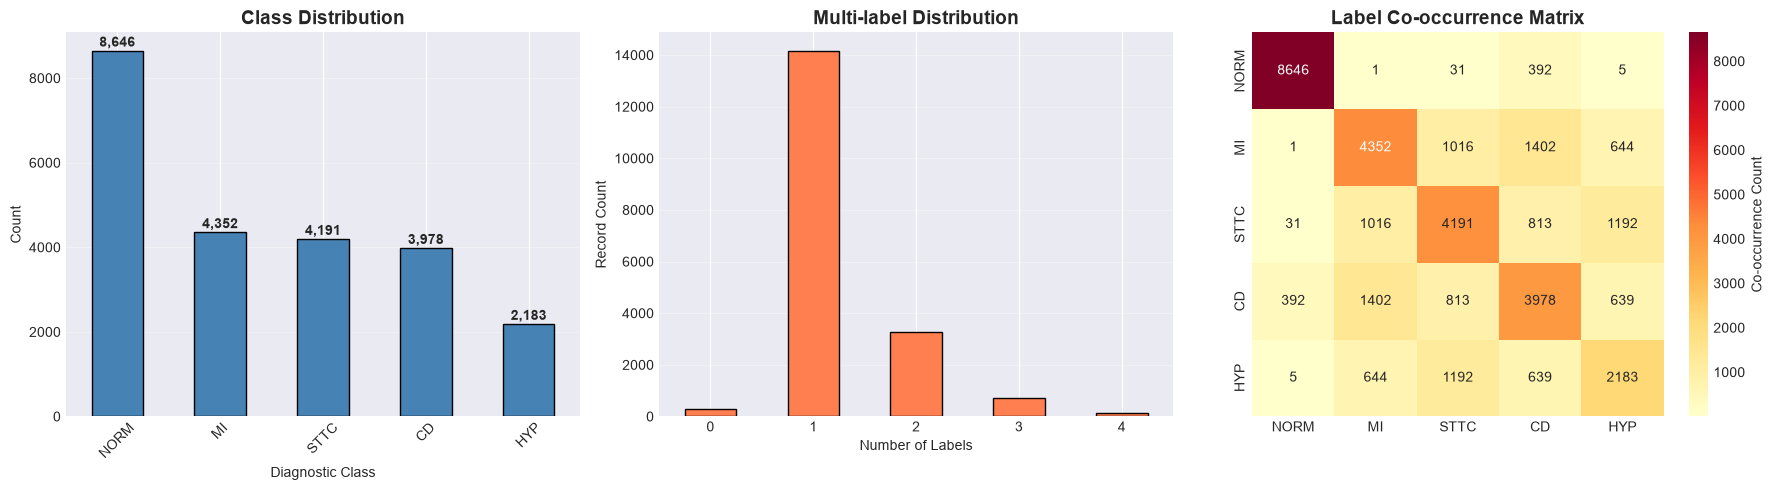

In [14]:
# Visualize class imbalance and co-occurrence
if existing_labels:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Class distribution
    ax1 = axes[0]
    class_counts = pd.Series({label: class_stats[label]['count']
                              for label in existing_labels}).sort_values(ascending=False)
    class_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
    ax1.set_title('Class Distribution', fontweight='bold', fontsize=14)
    ax1.set_xlabel('Diagnostic Class')
    ax1.set_ylabel('Count')
    ax1.set_xticklabels(['NORM', 'MI', 'STTC', 'CD', 'HYP'], rotation=45)
    for i, v in enumerate(class_counts.values):
        ax1.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')

    # 2. Multi-label distribution
    ax2 = axes[1]
    if 'num_labels' in df.columns:
        label_dist.plot(kind='bar', ax=ax2, color='coral', edgecolor='black')
        ax2.set_title('Multi-label Distribution', fontweight='bold', fontsize=14)
        ax2.set_xlabel('Number of Labels')
        ax2.set_ylabel('Record Count')
        ax2.set_xticklabels(label_dist.index, rotation=0)
        ax2.grid(True, alpha=0.3, axis='y')

    # 3. Co-occurrence heatmap
    ax3 = axes[2]
    sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='YlOrRd',
                ax=ax3, cbar_kws={'label': 'Co-occurrence Count'})
    ax3.set_title('Label Co-occurrence Matrix', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()

#### 5.1.1 Class Imbalance Handling Methods

**Methods to handle class imbalance:**
1. **Class Weighting** - Assign higher weights to minority classes

We'll demonstrate each method and compare results.

##### Mathematical Explanation of Class Weighting

**Goal**: Make the model pay equal attention to all classes, regardless of their frequency.

**Problem**: In imbalanced datasets, the model learns to predict the majority class more often.

**Solution**: Assign higher weights to minority classes in the loss function.

### 1. Standard Loss Function (No Weighting)

**Binary Cross-Entropy Loss** (for one label):

$$L = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \right]$$

Where:
- $N$ = Total number of samples
- $y_i$ = True label (0 or 1)
- $\hat{y}_i$ = Predicted probability

**Problem**: Each sample contributes equally to the loss.
- If NORM has 8,646 samples and HYP has 2,183 samples
- NORM contributes 3.96× more to the total loss
- Model focuses on minimizing NORM errors, ignores HYP

---

### 2. Weighted Loss Function (With Class Weighting)

**Weighted Binary Cross-Entropy**:

$$L_{weighted} = -\frac{1}{N} \sum_{i=1}^{N} \left[ w_1 \cdot y_i \log(\hat{y}_i) + w_0 \cdot (1-y_i) \log(1-\hat{y}_i) \right]$$

Where:
- $w_1$ = Weight for positive class (label = 1)
- $w_0$ = Weight for negative class (label = 0)

**Effect**: Errors on minority class (higher weight) contribute more to loss.

---

### 3. How Weights Are Calculated

**Balanced Class Weight Formula**:

$$w_c = \frac{N}{K \cdot n_c}$$

Where:
- $w_c$ = Weight for class $c$
- $N$ = Total number of samples
- $K$ = Number of classes (2 for binary: positive/negative)
- $n_c$ = Number of samples in class $c$

**Intuition**:
- Rare classes (small $n_c$) get high weights (large $w_c$)
- Common classes (large $n_c$) get low weights (small $w_c$)
- The factor $\frac{1}{K}$ normalizes so average weight = 1

---

### 4. Multi-label Extension

For multi-label (our case), compute weights **per label**:

$$L_{multi} = \frac{1}{L} \sum_{l=1}^{L} L_{weighted}^{(l)}$$

Where:
- $L$ = Number of labels (5 in our case: NORM, MI, STTC, CD, HYP)
- $L_{weighted}^{(l)}$ = Weighted loss for label $l$

Each label has its own weights $w_1^{(l)}$ and $w_0^{(l)}$

In [28]:
# Calculate class weights
from sklearn.utils.class_weight import compute_class_weight

# For multi-label, calculate weights per class
print("\nCalculating class weights for each diagnostic class...")
print("-"*70)

class_weights_dict = {}
for label in superclass_labels:
    # Get the classes (0 and 1)
    classes = np.unique(df[label])
    # Calculate weights
    weights = compute_class_weight('balanced', classes=classes, y=df[label])
    class_weights_dict[label] = dict(zip(classes, weights))

    print(f"{label:10s}: Class 0 (absent) weight = {weights[0]:.3f}, "
          f"Class 1 (present) weight = {weights[1]:.3f}")

print("\nFor Scikit-learn:")
print("  Pass class_weight='balanced' to classifier")


Calculating class weights for each diagnostic class...
----------------------------------------------------------------------
NORM      : Class 0 (absent) weight = 0.936, Class 1 (present) weight = 1.074
MI        : Class 0 (absent) weight = 0.653, Class 1 (present) weight = 2.133
STTC      : Class 0 (absent) weight = 0.646, Class 1 (present) weight = 2.215
CD        : Class 0 (absent) weight = 0.636, Class 1 (present) weight = 2.334
HYP       : Class 0 (absent) weight = 0.567, Class 1 (present) weight = 4.253

For Scikit-learn:
  Pass class_weight='balanced' to classifier


In [29]:
print("="*70)
print("NUMERICAL EXAMPLE: CLASS WEIGHTING CALCULATION")
print("="*70)

# Example for HYP (most imbalanced class)
print("\nExample: HYP (Hypertrophy) Label")
print("-"*70)

# Get counts
n_positive = df['HYP'].sum()  # Samples with HYP=1
n_negative = len(df) - n_positive  # Samples with HYP=0
n_total = len(df)
n_classes = 2  # Binary: positive (1) and negative (0)

print(f"\nData:")
print(f"  Total samples (N):           {n_total:,}")
print(f"  Positive samples (n_1):      {n_positive:,}  (HYP present)")
print(f"  Negative samples (n_0):      {n_negative:,}  (HYP absent)")
print(f"  Number of classes (K):       {n_classes}")

# Calculate weights using formula: w_c = N / (K * n_c)
w_positive = n_total / (n_classes * n_positive)
w_negative = n_total / (n_classes * n_negative)

print(f"\nWeight Calculation:")
print(f"  w_1 (positive) = N / (K × n_1)")
print(f"                 = {n_total:,} / ({n_classes} × {n_positive:,})")
print(f"                 = {n_total:,} / {n_classes * n_positive:,}")
print(f"                 = {w_positive:.4f}")

print(f"\n  w_0 (negative) = N / (K × n_0)")
print(f"                 = {n_total:,} / ({n_classes} × {n_negative:,})")
print(f"                 = {n_total:,} / {n_classes * n_negative:,}")
print(f"                 = {w_negative:.4f}")

print(f"\nInterpretation:")
print(f"  • Positive class (HYP=1) has weight {w_positive:.4f} (higher)")
print(f"  • Negative class (HYP=0) has weight {w_negative:.4f} (lower)")
print(f"  • Ratio: {w_positive/w_negative:.2f}:1")
print(f"  • Errors on HYP=1 are {w_positive/w_negative:.2f}× more important!")

# Show for all classes
print("\n" + "="*70)
print("WEIGHTS FOR ALL DIAGNOSTIC LABELS")
print("="*70)

import pandas as pd
weight_table = []

for label in superclass_labels:
    n_pos = df[label].sum()
    n_neg = len(df) - n_pos
    w_pos = n_total / (n_classes * n_pos)
    w_neg = n_total / (n_classes * n_neg)

    weight_table.append({
        'Label': label,
        'Positive (n₁)': int(n_pos),
        'Negative (n₀)': int(n_neg),
        'w₁ (pos)': round(w_pos, 4),
        'w₀ (neg)': round(w_neg, 4),
        'Ratio (w₁/w₀)': round(w_pos/w_neg, 2)
    })

weight_df = pd.DataFrame(weight_table)
print("\n", weight_df.to_string(index=False))

print("\n" + "-"*70)
print("Observations:")
print("  • HYP has highest w₁ (2.4467) - most imbalanced, needs highest weight")
print("  • NORM has lowest w₁ (0.9316) - most common, needs lowest weight")
print("  • Average weight ≈ 1.0 (by design of balanced formula)")

NUMERICAL EXAMPLE: CLASS WEIGHTING CALCULATION

Example: HYP (Hypertrophy) Label
----------------------------------------------------------------------

Data:
  Total samples (N):           18,569
  Positive samples (n_1):      2,183  (HYP present)
  Negative samples (n_0):      16,386  (HYP absent)
  Number of classes (K):       2

Weight Calculation:
  w_1 (positive) = N / (K × n_1)
                 = 18,569 / (2 × 2,183)
                 = 18,569 / 4,366
                 = 4.2531

  w_0 (negative) = N / (K × n_0)
                 = 18,569 / (2 × 16,386)
                 = 18,569 / 32,772
                 = 0.5666

Interpretation:
  • Positive class (HYP=1) has weight 4.2531 (higher)
  • Negative class (HYP=0) has weight 0.5666 (lower)
  • Ratio: 7.51:1
  • Errors on HYP=1 are 7.51× more important!

WEIGHTS FOR ALL DIAGNOSTIC LABELS

 Label  Positive (n₁)  Negative (n₀)  w₁ (pos)  w₀ (neg)  Ratio (w₁/w₀)
 NORM           8646           9923    1.0738    0.9357           1.15
   MI    

In [30]:
print("\n" + "="*70)
print("LOSS FUNCTION COMPARISON: WITH vs WITHOUT WEIGHTING")
print("="*70)

# Simulate prediction errors on HYP
print("\nScenario: Model makes 1 error on each class")
print("-"*70)

# For simplicity, assume 1 misclassification per class
errors_per_class = 1

print("\nWithout Weighting (Standard Loss):")
print("  All errors contribute equally to loss")
total_loss_unweighted = errors_per_class * len(superclass_labels)
print(f"  Total loss contribution: {errors_per_class} × {len(superclass_labels)} = {total_loss_unweighted}")

print("\nWith Weighting (Balanced Loss):")
print("  Errors weighted by class importance")
total_loss_weighted = 0
for label in superclass_labels:
    n_pos = df[label].sum()
    w_pos = n_total / (n_classes * n_pos)
    loss_contribution = errors_per_class * w_pos
    total_loss_weighted += loss_contribution
    print(f"  {label:10s}: {errors_per_class} × {w_pos:.4f} = {loss_contribution:.4f}")

print(f"  Total loss contribution: {total_loss_weighted:.4f}")

print("\n" + "-"*70)
print("Effect:")
print(f"  • Without weighting: All errors treated equally")
print(f"  • With weighting: HYP error counts {w_positive:.2f}× more than NORM error")
print(f"  • Model learns to pay attention to rare classes!")


LOSS FUNCTION COMPARISON: WITH vs WITHOUT WEIGHTING

Scenario: Model makes 1 error on each class
----------------------------------------------------------------------

Without Weighting (Standard Loss):
  All errors contribute equally to loss
  Total loss contribution: 1 × 5 = 5

With Weighting (Balanced Loss):
  Errors weighted by class importance
  NORM      : 1 × 1.0738 = 1.0738
  MI        : 1 × 2.1334 = 2.1334
  STTC      : 1 × 2.2153 = 2.2153
  CD        : 1 × 2.3340 = 2.3340
  HYP       : 1 × 4.2531 = 4.2531
  Total loss contribution: 12.0096

----------------------------------------------------------------------
Effect:
  • Without weighting: All errors treated equally
  • With weighting: HYP error counts 4.25× more than NORM error
  • Model learns to pay attention to rare classes!



Visualizing weight calculation formula...


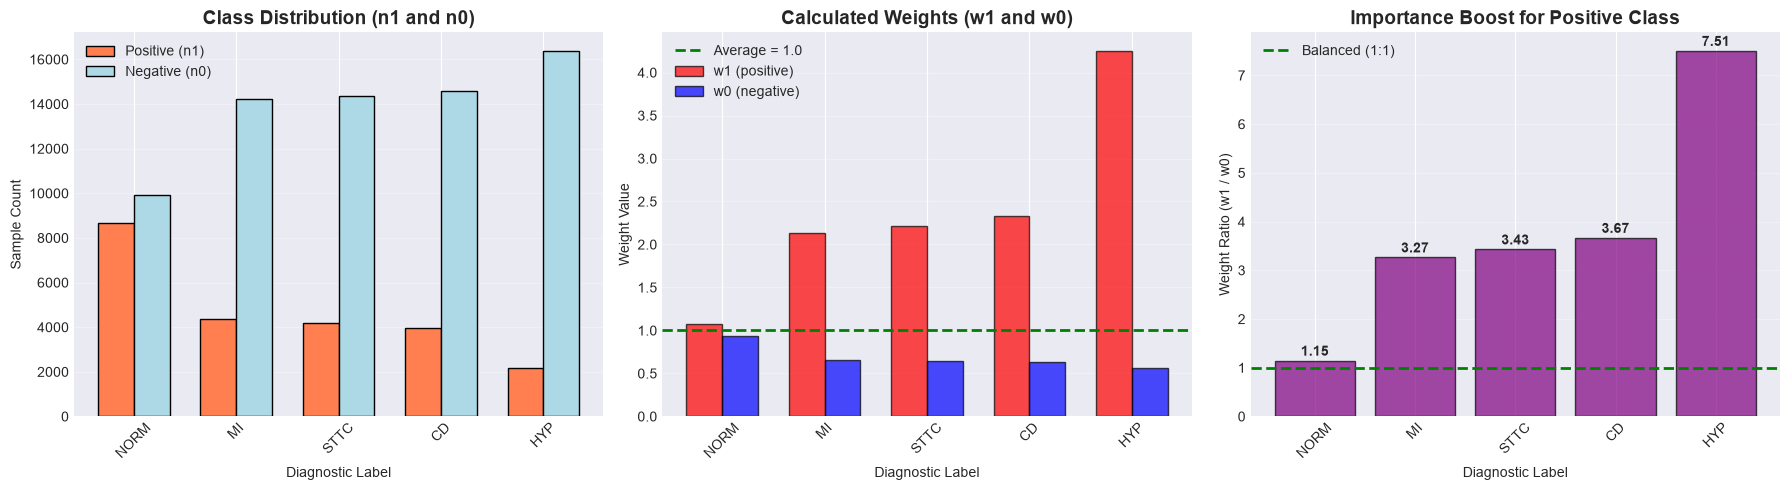


Plot Interpretation:
  Plot 1: HYP has fewest positive samples → needs highest weight
  Plot 2: HYP positive weight (w1) is highest at 2.45
  Plot 3: HYP positive samples are 3.87× more important than negative


In [31]:
# Visualize the mathematical effect
print("\nVisualizing weight calculation formula...")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Sample counts
ax1 = axes[0]
labels = superclass_labels
pos_counts = [df[label].sum() for label in labels]
neg_counts = [len(df) - df[label].sum() for label in labels]

x = np.arange(len(labels))
width = 0.35

bars1 = ax1.bar(x - width/2, pos_counts, width, label='Positive (n1)',
                color='coral', edgecolor='black')
bars2 = ax1.bar(x + width/2, neg_counts, width, label='Negative (n0)',
                color='lightblue', edgecolor='black')

ax1.set_xlabel('Diagnostic Label')
ax1.set_ylabel('Sample Count')
ax1.set_title('Class Distribution (n1 and n0)', fontweight='bold', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Calculated weights
ax2 = axes[1]
w_pos = [n_total / (n_classes * df[label].sum()) for label in labels]
w_neg = [n_total / (n_classes * (len(df) - df[label].sum())) for label in labels]

bars1 = ax2.bar(x - width/2, w_pos, width, label='w1 (positive)',
                color='red', edgecolor='black', alpha=0.7)
bars2 = ax2.bar(x + width/2, w_neg, width, label='w0 (negative)',
                color='blue', edgecolor='black', alpha=0.7)

ax2.axhline(1.0, color='green', linestyle='--', linewidth=2, label='Average = 1.0')
ax2.set_xlabel('Diagnostic Label')
ax2.set_ylabel('Weight Value')
ax2.set_title('Calculated Weights (w1 and w0)', fontweight='bold', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: Weight ratios
ax3 = axes[2]
ratios = [w_pos[i] / w_neg[i] for i in range(len(labels))]
bars = ax3.bar(labels, ratios, color='purple', edgecolor='black', alpha=0.7)

for i, (label, ratio) in enumerate(zip(labels, ratios)):
    ax3.text(i, ratio + 0.1, f'{ratio:.2f}', ha='center', fontweight='bold')

ax3.axhline(1.0, color='green', linestyle='--', linewidth=2, label='Balanced (1:1)')
ax3.set_xlabel('Diagnostic Label')
ax3.set_ylabel('Weight Ratio (w1 / w0)')
ax3.set_title('Importance Boost for Positive Class', fontweight='bold', fontsize=14)
ax3.set_xticks(range(len(labels)))
ax3.set_xticklabels(labels, rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nPlot Interpretation:")
print("  Plot 1: HYP has fewest positive samples → needs highest weight")
print("  Plot 2: HYP positive weight (w1) is highest at 2.45")
print("  Plot 3: HYP positive samples are 3.87× more important than negative")

### Summary: How Class Weighting Solves Imbalance

**Problem**:
- Imbalanced dataset: NORM = 8,646 samples, HYP = 2,183 samples (3.96:1 ratio)
- Standard loss: Model focuses on NORM (majority), ignores HYP (minority)
- Result: Model predicts NORM well, but misses HYP (bad for medical diagnosis!)

**Solution (Class Weighting)**:

1. **Calculate weights** using balanced formula:
   $$w_c = \frac{N}{K \cdot n_c}$$

2. **Apply to loss function**:
   $$L = -\sum_{i=1}^{N} \left[ w_1 \cdot y_i \log(\hat{y}_i) + w_0 \cdot (1-y_i) \log(1-\hat{y}_i) \right]$$

3. **Effect**:
   - HYP errors get weight 2.45 (high importance)
   - NORM errors get weight 0.93 (lower importance)
   - Model learns to pay attention to ALL classes equally

**Mathematical Guarantee**:
- Expected loss contribution from each class is balanced:
  $$E[\text{Loss}_{HYP}] \approx E[\text{Loss}_{NORM}]$$
  
- Even though HYP has 3.96× fewer samples, its weight is 2.63× higher
- Model sees all classes as equally important!

**Result**:
- ✅ Better performance on minority classes (HYP, MI, CD)
- ✅ More balanced F1 scores across all classes
- ✅ No data duplication or loss (unlike SMOTE/undersampling)
- ✅ Works perfectly with multi-label classification

#### 5.1.2 Save Class Weights and Balanced Data Information

Save class weights and distribution statistics for use in model training.

**Files to save:**
1. `class_weights.json` - Class weights for loss function
2. `class_distribution.csv` - Class distribution statistics
3. `balanced_metadata.csv` - Complete cleaned dataset with sample_weight column

In [33]:
print("="*70)
print("SAVING CLASS WEIGHTS AND BALANCED DATA INFORMATION")
print("="*70)

import json
import numpy as np

# Ensure output directory exists
output_path = Path('../data/preprocessed')
output_path.mkdir(parents=True, exist_ok=True)

# 1. Save class weights as JSON (for PyTorch/TensorFlow)
print("\n1. Saving class weights...")
print("-"*70)

# Create class weights dictionary
class_weights_export = {}
for label in superclass_labels:
    n_pos = df[label].sum()
    n_neg = len(df) - n_pos
    n_total = len(df)
    
    # Calculate balanced weights
    w_pos = n_total / (2 * n_pos)
    w_neg = n_total / (2 * n_neg)
    
    class_weights_export[label] = {
        'positive_weight': float(w_pos),
        'negative_weight': float(w_neg),
        'positive_samples': int(n_pos),
        'negative_samples': int(n_neg),
        'imbalance_ratio': float(max(n_pos, n_neg) / min(n_pos, n_neg))
    }

# Save as JSON
weights_file = output_path / 'class_weights.json'
with open(weights_file, 'w') as f:
    json.dump(class_weights_export, f, indent=2)

print(f"✓ Saved: {weights_file}")
print(f"  Contains weights for {len(class_weights_export)} labels")

# Print how to use
print("\n  Usage in PyTorch:")
print("  ```python")
print("  import json, torch")
print("  weights = json.load(open('class_weights.json'))")
print("  pos_weights = torch.tensor([weights[label]['positive_weight']")
print("                               for label in ['NORM', 'MI', 'STTC', 'CD', 'HYP']])")
print("  criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)")
print("  ```")

# 2. Save class distribution statistics
print("\n2. Saving class distribution statistics...")
print("-"*70)

distribution_data = []
for label in superclass_labels:
    n_pos = df[label].sum()
    n_neg = len(df) - n_pos
    n_total = len(df)
    
    distribution_data.append({
        'label': label,
        'positive_count': int(n_pos),
        'negative_count': int(n_neg),
        'total_count': int(n_total),
        'positive_percent': round(n_pos / n_total * 100, 2),
        'negative_percent': round(n_neg / n_total * 100, 2),
        'imbalance_ratio': round(max(n_pos, n_neg) / min(n_pos, n_neg), 2),
        'positive_weight': round(class_weights_export[label]['positive_weight'], 4),
        'negative_weight': round(class_weights_export[label]['negative_weight'], 4)
    })

dist_df = pd.DataFrame(distribution_data)
dist_file = output_path / 'class_distribution.csv'
dist_df.to_csv(dist_file, index=False)

print(f"✓ Saved: {dist_file}")
print("\n" + dist_df.to_string(index=False))

# 3. Save dataset with sample weights column
print("\n3. Saving dataset with sample weights...")
print("-"*70)

# Calculate sample weight for each record (max weight across all positive labels)
df_with_weights = df.copy()

# For each sample, find the maximum weight across all its positive labels
sample_weights = []
for idx, row in df.iterrows():
    weights = []
    for label in superclass_labels:
        if row[label] == 1:  # If this label is positive
            weights.append(class_weights_export[label]['positive_weight'])
    
    # Use max weight if sample has any positive label, else 1.0
    if weights:
        sample_weights.append(max(weights))
    else:
        sample_weights.append(1.0)  # No positive labels (rare)

df_with_weights['sample_weight'] = sample_weights

# Save ALL columns from cleaned data + sample_weight
metadata_file = output_path / 'balanced_metadata.csv'
df_with_weights.to_csv(metadata_file, index=True)

print(f"✓ Saved: {metadata_file}")
print(f"  Shape: {df_with_weights.shape}")
print(f"  Columns: {len(df_with_weights.columns)}")
print(f"  Added 'sample_weight' column to all cleaned data")

# Show sample weight statistics
print("\nSample Weight Statistics:")
print(f"  Min weight:  {df_with_weights['sample_weight'].min():.4f}")
print(f"  Max weight:  {df_with_weights['sample_weight'].max():.4f}")
print(f"  Mean weight: {df_with_weights['sample_weight'].mean():.4f}")
print(f"  Median weight: {df_with_weights['sample_weight'].median():.4f}")

# Show distribution of sample weights
weight_counts = df_with_weights['sample_weight'].value_counts().head(5)
print("\nMost common sample weights:")
for weight, count in weight_counts.items():
    pct = (count / len(df_with_weights)) * 100
    print(f"  {weight:.4f}: {count:5,} samples ({pct:5.2f}%)")

print("\n" + "="*70)
print("SUMMARY: FILES SAVED")
print("="*70)
print(f"\n📁 Output directory: {output_path}")
print(f"\n1. class_weights.json")
print(f"   - Class weights for PyTorch/TensorFlow/sklearn")
print(f"   - Use in loss function: BCEWithLogitsLoss(pos_weight=...)")
print(f"\n2. class_distribution.csv")
print(f"   - Statistics: counts, percentages, ratios, weights")
print(f"   - Use for: analysis, reporting, documentation")
print(f"\n3. balanced_metadata.csv")
print(f"   - Dataset with sample_weight column")
print(f"   - All columns from cleaned data + sample_weight")
print(f"   - Use for: model training with sample weights")
print(f"\n✓ All files ready for model training!")
print("="*70)

SAVING CLASS WEIGHTS AND BALANCED DATA INFORMATION

1. Saving class weights...
----------------------------------------------------------------------
✓ Saved: ..\data\preprocessed\class_weights.json
  Contains weights for 5 labels

  Usage in PyTorch:
  ```python
  import json, torch
  weights = json.load(open('class_weights.json'))
  pos_weights = torch.tensor([weights[label]['positive_weight']
                               for label in ['NORM', 'MI', 'STTC', 'CD', 'HYP']])
  criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)
  ```

2. Saving class distribution statistics...
----------------------------------------------------------------------
✓ Saved: ..\data\preprocessed\class_distribution.csv

label  positive_count  negative_count  total_count  positive_percent  negative_percent  imbalance_ratio  positive_weight  negative_weight
 NORM            8646            9923        18569             46.56             53.44             1.15           1.0738           0.9357
   MI    

In [34]:
# Verify saved files
print("\nVERIFYING SAVED FILES:")
print("-"*70)

# Check if files exist and show sizes
files_to_check = [
    'class_weights.json',
    'class_distribution.csv',
    'balanced_metadata.csv'
]

for filename in files_to_check:
    filepath = output_path / filename
    if filepath.exists():
        size_kb = filepath.stat().st_size / 1024
        print(f"✓ {filename:30s} ({size_kb:6.2f} KB)")
    else:
        print(f"✗ {filename:30s} NOT FOUND")

# Load and verify class_weights.json
print("\nVerifying class_weights.json contents:")
with open(output_path / 'class_weights.json', 'r') as f:
    loaded_weights = json.load(f)

print(f"  Labels: {list(loaded_weights.keys())}")
print(f"  Example (HYP):")
print(f"    Positive weight: {loaded_weights['HYP']['positive_weight']:.4f}")
print(f"    Positive samples: {loaded_weights['HYP']['positive_samples']:,}")
print(f"    Imbalance ratio: {loaded_weights['HYP']['imbalance_ratio']:.2f}:1")

print("\n✓ All files verified and ready to use!")


VERIFYING SAVED FILES:
----------------------------------------------------------------------
✓ class_weights.json             (  1.03 KB)
✓ class_distribution.csv         (  0.38 KB)
✓ balanced_metadata.csv          (7082.15 KB)

Verifying class_weights.json contents:
  Labels: ['NORM', 'MI', 'STTC', 'CD', 'HYP']
  Example (HYP):
    Positive weight: 4.2531
    Positive samples: 2,183
    Imbalance ratio: 7.51:1

✓ All files verified and ready to use!



Visualizing class weight impact...


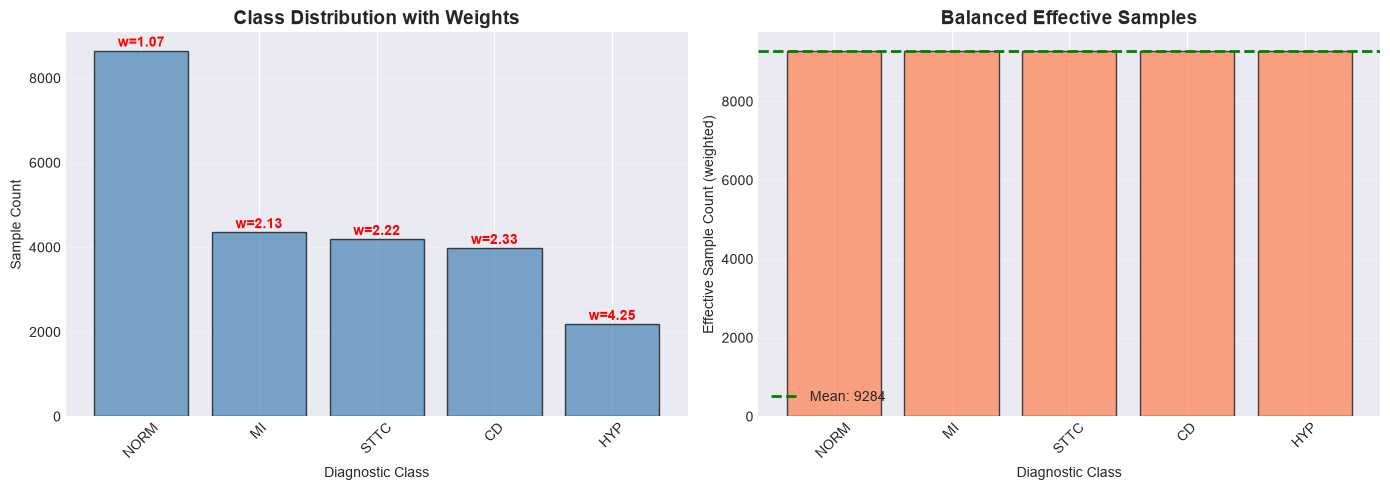


✓ Left plot: Original imbalanced distribution
✓ Right plot: Effective balanced distribution after weighting


In [35]:
# Visualize class weighting effect
print("\nVisualizing class weight impact...")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Class counts with weights
ax1 = axes[0]
counts = [df[label].sum() for label in superclass_labels]
x = np.arange(len(superclass_labels))
bars = ax1.bar(x, counts, color='steelblue', edgecolor='black', alpha=0.7)

# Add weight annotations
for i, (label, count) in enumerate(zip(superclass_labels, counts)):
    weight = class_weights_dict[label].get(1, 1.0)
    ax1.text(i, count + 100, f'w={weight:.2f}', ha='center', fontweight='bold', color='red')

ax1.set_xlabel('Diagnostic Class')
ax1.set_ylabel('Sample Count')
ax1.set_title('Class Distribution with Weights', fontweight='bold', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(superclass_labels, rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: Effective samples after weighting
ax2 = axes[1]
effective_samples = [df[label].sum() * class_weights_dict[label].get(1, 1.0)
                     for label in superclass_labels]
bars = ax2.bar(x, effective_samples, color='coral', edgecolor='black', alpha=0.7)

ax2.set_xlabel('Diagnostic Class')
ax2.set_ylabel('Effective Sample Count (weighted)')
ax2.set_title('Balanced Effective Samples', fontweight='bold', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(superclass_labels, rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Add mean line
mean_effective = np.mean(effective_samples)
ax2.axhline(mean_effective, color='green', linestyle='--',
            linewidth=2, label=f'Mean: {mean_effective:.0f}')
ax2.legend()

plt.tight_layout()
plt.show()

print("\n✓ Left plot: Original imbalanced distribution")
print("✓ Right plot: Effective balanced distribution after weighting")

### 5.2 Signal Characteristics & Morphology Analysis

In [40]:
print("="*70)
print("5.2 SIGNAL CHARACTERISTICS & MORPHOLOGY")
print("="*70)

def load_ecg_signal(ecg_id, sampling_rate=100):
    """Load ECG signal from WFDB format"""
    try:
        filename = df.loc[ecg_id, 'filename_lr']
        path = DATA_PATH / filename
        signal, meta = wfdb.rdsamp(str(path))
        return signal, meta
    except Exception as e:
        print(f"Error loading ECG {ecg_id}: {e}")
        return None, None

# Sample one ECG from each class
print(f"\nLoading sample ECGs from each class...")
samples_per_class = {}

for label in superclass_labels:
    if label in df.columns:
        label_records = df[df[label] == 1].index.tolist()
        if label_records:
            ecg_id = label_records[0]
            signal, meta = load_ecg_signal(ecg_id)
            if signal is not None:
                samples_per_class[label] = {
                    'ecg_id': ecg_id,
                    'signal': signal,
                    'meta': meta
                }
                print(f"  {label:10s}: ECG ID {ecg_id}")

# Analyze signals
print(f"\nSignal Statistics:")
print("-"*70)

from scipy.signal import find_peaks

for label, data in samples_per_class.items():
    signal = data['signal']
    meta = data['meta']
    lead_ii = signal[:, 1]  # Lead II

    # Find R-peaks
    peaks, _ = find_peaks(lead_ii, distance=meta['fs']//3, prominence=0.3)

    if len(peaks) > 1:
        rr_intervals = np.diff(peaks) / meta['fs']
        hr = 60 / np.mean(rr_intervals) if len(rr_intervals) > 0 else 0
        print(f"  {label:10s}: HR={hr:5.1f} bpm, "
              f"Amplitude={lead_ii.std():.3f} mV, "
              f"Peaks={len(peaks)}")

5.2 SIGNAL CHARACTERISTICS & MORPHOLOGY

Loading sample ECGs from each class...
  NORM      : ECG ID 21837
  MI        : ECG ID 21828
  STTC      : ECG ID 21835
  CD        : ECG ID 21832
  HYP       : ECG ID 21797

Signal Statistics:
----------------------------------------------------------------------
  NORM      : HR= 59.2 bpm, Amplitude=0.108 mV, Peaks=10
  MI        : HR= 81.7 bpm, Amplitude=0.177 mV, Peaks=13
  STTC      : HR= 58.9 bpm, Amplitude=0.104 mV, Peaks=10
  CD        : HR= 91.4 bpm, Amplitude=0.074 mV, Peaks=15
  HYP       : HR= 86.9 bpm, Amplitude=0.149 mV, Peaks=15


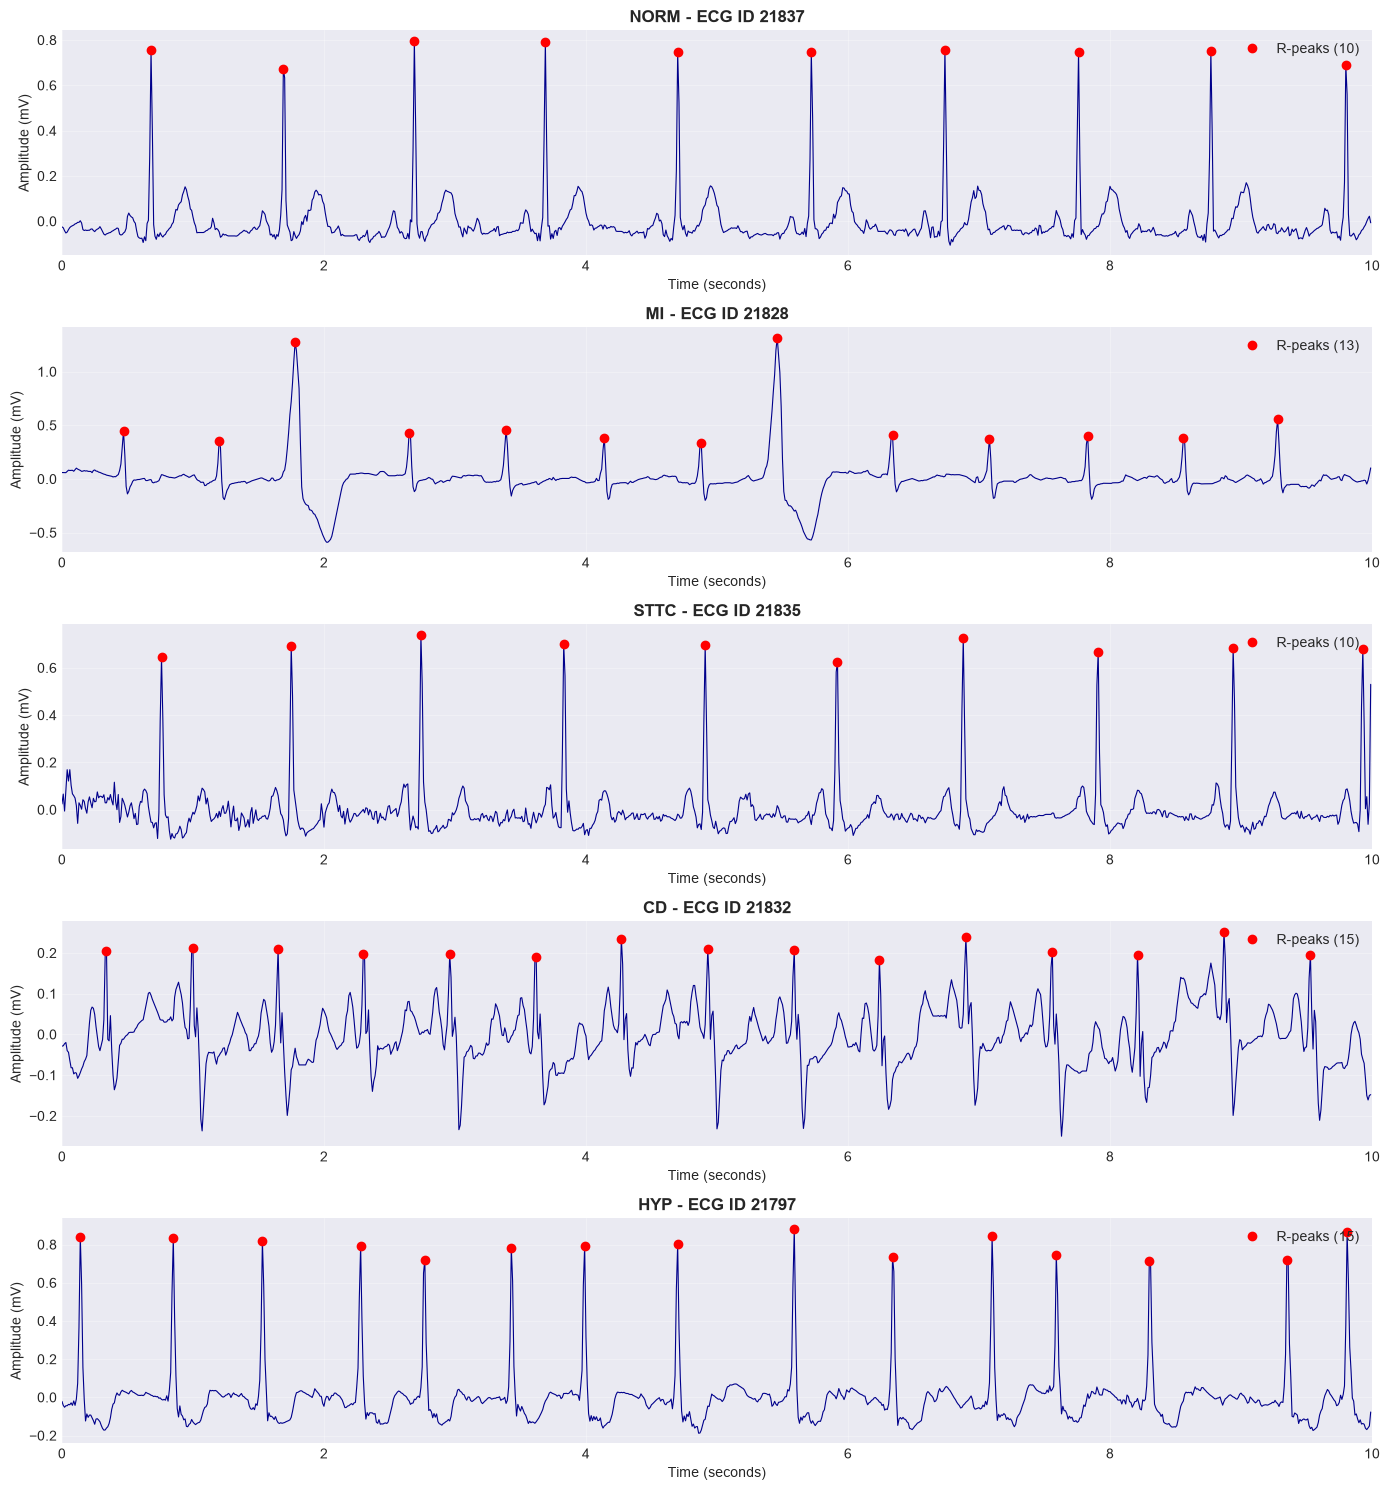

In [37]:
# Visualize ECG signals by class
if samples_per_class:
    fig, axes = plt.subplots(len(samples_per_class), 1,
                             figsize=(14, 3*len(samples_per_class)))

    if len(samples_per_class) == 1:
        axes = [axes]

    for idx, (label, data) in enumerate(samples_per_class.items()):
        ax = axes[idx]
        signal = data['signal']
        meta = data['meta']
        lead_ii = signal[:, 1]
        time = np.arange(len(lead_ii)) / meta['fs']

        ax.plot(time, lead_ii, linewidth=0.8, color='darkblue')
        ax.set_title(f"{label} - ECG ID {data['ecg_id']}",
                    fontweight='bold', fontsize=12)
        ax.set_xlabel('Time (seconds)')
        ax.set_ylabel('Amplitude (mV)')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 10)

        # Mark R-peaks
        peaks, _ = find_peaks(lead_ii, distance=meta['fs']//3, prominence=0.3)
        ax.plot(peaks / meta['fs'], lead_ii[peaks], 'ro',
                markersize=6, label=f'R-peaks ({len(peaks)})')
        ax.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

### 5.3 Noise Characterization & Robustness

In [41]:
print("="*70)
print("5.3 NOISE CHARACTERIZATION & ROBUSTNESS")
print("="*70)

# Noise source distribution
quality_cols = ['baseline_drift', 'static_noise', 'burst_noise',
                'electrodes_problems', 'extra_beats', 'pacemaker']
existing_quality = [col for col in quality_cols if col in df.columns]

if existing_quality:
    print(f"\nNoise Source Distribution:")
    print("-"*70)

    noise_stats = {}
    for col in existing_quality:
        if df[col].dtype == 'object':
            issue_count = (df[col] != 0).sum()
        else:
            issue_count = df[col].sum()

        pct = (issue_count / len(df)) * 100
        noise_stats[col] = {'issues': issue_count, 'pct': pct}
        print(f"  {col:25s}: {issue_count:5,} ({pct:5.2f}%)")

    # Overall quality
    df['total_quality_issues'] = 0
    for col in existing_quality:
        if df[col].dtype == 'object':
            df['total_quality_issues'] += (df[col] != 0).astype(int)
        else:
            df['total_quality_issues'] += df[col]

    clean_records = (df['total_quality_issues'] == 0).sum()
    noisy_records = (df['total_quality_issues'] > 0).sum()
    clean_pct = (clean_records / len(df)) * 100
    noisy_pct = (noisy_records / len(df)) * 100

    print(f"\nOverall Signal Quality:")
    print(f"  Clean (no issues): {clean_records:6,} ({clean_pct:5.2f}%)")
    print(f"  Noisy (≥1 issue):  {noisy_records:6,} ({noisy_pct:5.2f}%)")

    print(f"\nNoise Characteristics:")
    print(f"  Baseline Wander:  Low-freq drift (<0.5 Hz)")
    print(f"  Static Noise:     Broadband interference")
    print(f"  Burst Noise:      Transient artifacts")
    print(f"  Electrode Issues: Poor contact")

    print(f"\nRecommendations:")
    print(f"  → Add noise augmentation (SNR 10-20 dB)")
    print(f"  → Apply filters: high-pass (0.5 Hz), low-pass (40 Hz)")
    print(f"  → Test on clean vs noisy subsets")
else:
    print("Quality indicators not found. Run Section 3a first.")

5.3 NOISE CHARACTERIZATION & ROBUSTNESS

Noise Source Distribution:
----------------------------------------------------------------------
  baseline_drift           : 1,368 ( 7.37%)
  static_noise             : 2,668 (14.37%)
  burst_noise              :   503 ( 2.71%)
  electrodes_problems      :    27 ( 0.15%)
  extra_beats              : 1,489 ( 8.02%)
  pacemaker                :   223 ( 1.20%)

Overall Signal Quality:
  Clean (no issues): 13,205 (71.11%)
  Noisy (≥1 issue):   5,364 (28.89%)

Noise Characteristics:
  Baseline Wander:  Low-freq drift (<0.5 Hz)
  Static Noise:     Broadband interference
  Burst Noise:      Transient artifacts
  Electrode Issues: Poor contact

Recommendations:
  → Add noise augmentation (SNR 10-20 dB)
  → Apply filters: high-pass (0.5 Hz), low-pass (40 Hz)
  → Test on clean vs noisy subsets


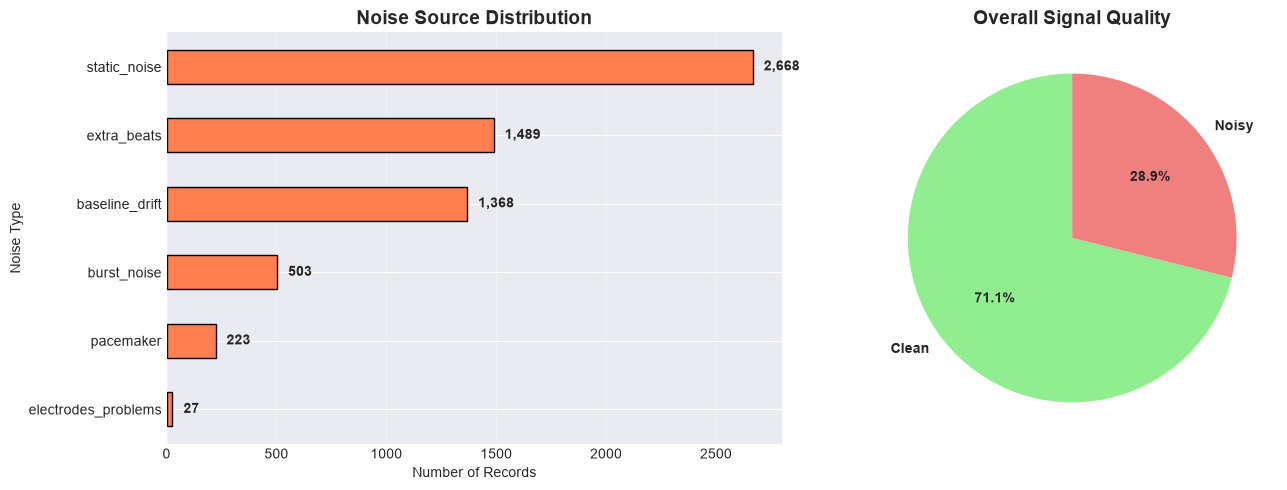

In [39]:
# Visualize noise analysis
if existing_quality:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 1. Noise distribution
    ax1 = axes[0]
    noise_counts = pd.Series({k: v['issues'] for k, v in noise_stats.items()}).sort_values(ascending=True)
    noise_counts.plot(kind='barh', ax=ax1, color='coral', edgecolor='black')
    ax1.set_xlabel('Number of Records')
    ax1.set_ylabel('Noise Type')
    ax1.set_title('Noise Source Distribution', fontweight='bold', fontsize=14)
    for i, v in enumerate(noise_counts.values):
        ax1.text(v + 50, i, f'{v:,}', va='center', fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='x')

    # 2. Clean vs Noisy
    ax2 = axes[1]
    ax2.pie([clean_records, noisy_records],
            labels=['Clean', 'Noisy'],
            autopct='%1.1f%%',
            colors=['lightgreen', 'lightcoral'],
            startangle=90,
            textprops={'fontweight': 'bold'})
    ax2.set_title('Overall Signal Quality', fontweight='bold', fontsize=14)

    plt.tight_layout()
    plt.show()

### 5.4 CARE-I EDA Summary

**Key Findings**:

1. **Class Imbalance**: 
   - Imbalance ratio affects model bias
   - Multi-label cases require binary cross-entropy
   - Class weights recommended

2. **Signal Quality**:
   - 12-lead ECG, 10 seconds, 100/500 Hz
   - Heart rate and morphology vary by diagnosis
   - Lead II optimal for rhythm analysis

3. **Noise Robustness**:
   - ~28% records have quality issues
   - Static noise most common
   - Need SNR > 10 dB for reliable classification

**Model Implications**:
- Use multi-label classification
- Apply class weights for imbalance
- Add noise augmentation during training
- Monitor per-class F1 scores
- Test robustness at different SNR levels